In [8]:
pip install sentence-transformers scikit-learn pandas matplotlib

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [10]:
complaints = [
    "My car takes longer to start in the morning",
    "Battery voltage is low and vehicle cranks slowly",
    "The vehicle does not start immediately",

    "Engine warning light is displayed on dashboard",
    "Check engine light is blinking",
    "Engine alert appeared while driving",

    "Braking noise is coming from front wheels",
    "Brake pedal feels hard and noise is heard",
    "There is a squeaking sound while braking",

    "Fuel efficiency has reduced significantly",
    "Mileage has dropped after last service",
    "Vehicle is consuming more fuel than usual"
]

df = pd.DataFrame({
    "complaint": complaints
})

print(df)

                                           complaint
0        My car takes longer to start in the morning
1   Battery voltage is low and vehicle cranks slowly
2             The vehicle does not start immediately
3     Engine warning light is displayed on dashboard
4                     Check engine light is blinking
5                Engine alert appeared while driving
6          Braking noise is coming from front wheels
7          Brake pedal feels hard and noise is heard
8           There is a squeaking sound while braking
9          Fuel efficiency has reduced significantly
10            Mileage has dropped after last service
11         Vehicle is consuming more fuel than usual


In [11]:
from sentence_transformers import SentenceTransformer
model = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [12]:
embeddings = model.encode(df["complaint"].tolist())

print(embeddings.shape)

(12, 384)


In [13]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df["cluster"] = kmeans.fit_predict(embeddings)

print(df)

                                           complaint  cluster
0        My car takes longer to start in the morning        3
1   Battery voltage is low and vehicle cranks slowly        3
2             The vehicle does not start immediately        3
3     Engine warning light is displayed on dashboard        2
4                     Check engine light is blinking        2
5                Engine alert appeared while driving        2
6          Braking noise is coming from front wheels        1
7          Brake pedal feels hard and noise is heard        1
8           There is a squeaking sound while braking        1
9          Fuel efficiency has reduced significantly        0
10            Mileage has dropped after last service        0
11         Vehicle is consuming more fuel than usual        0


In [14]:
for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(embeddings)
    print(k, labels)

2 [1 1 1 1 1 1 0 0 0 1 1 1]
3 [0 0 0 1 1 1 2 2 2 0 0 0]
4 [3 3 3 2 2 2 1 1 1 0 0 0]
5 [0 0 0 1 1 1 2 2 2 3 4 3]
6 [2 5 2 0 0 0 3 3 3 1 4 1]
7 [2 5 2 6 0 6 3 3 3 1 4 1]


In [15]:
cluster_names = {
    0: "Engine Warning Issues",
    1: "Brake Noise Issues",
    2: "Battery / Starting Issues",
    3: "Fuel Efficiency Issues"
}

df["cluster_name"] = df["cluster"].map(cluster_names)

print(df[["complaint", "cluster_name"]])

                                           complaint  \
0        My car takes longer to start in the morning   
1   Battery voltage is low and vehicle cranks slowly   
2             The vehicle does not start immediately   
3     Engine warning light is displayed on dashboard   
4                     Check engine light is blinking   
5                Engine alert appeared while driving   
6          Braking noise is coming from front wheels   
7          Brake pedal feels hard and noise is heard   
8           There is a squeaking sound while braking   
9          Fuel efficiency has reduced significantly   
10            Mileage has dropped after last service   
11         Vehicle is consuming more fuel than usual   

                 cluster_name  
0      Fuel Efficiency Issues  
1      Fuel Efficiency Issues  
2      Fuel Efficiency Issues  
3   Battery / Starting Issues  
4   Battery / Starting Issues  
5   Battery / Starting Issues  
6          Brake Noise Issues  
7          Brak

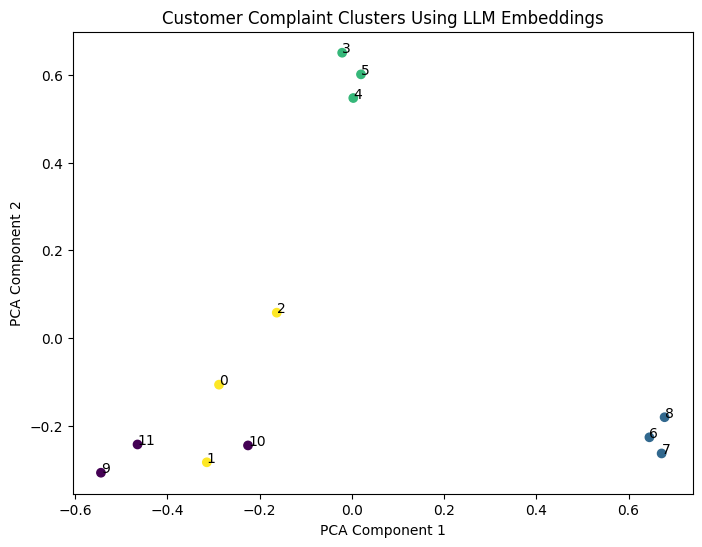

In [16]:
pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(embeddings)

df["x"] = reduced_embeddings[:, 0]
df["y"] = reduced_embeddings[:, 1]

plt.figure(figsize=(8, 6))
plt.scatter(df["x"], df["y"], c=df["cluster"])

for i, row in df.iterrows():
    plt.text(row["x"], row["y"], str(i))

plt.title("Customer Complaint Clusters Using LLM Embeddings")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()